In [1]:
import torch

In [2]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

print('Selected device:', device)

Selected device: cuda


In [3]:
import random

### Reading data set ###

with open('../data-sets/Bijbel.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: 22 *Velen zullen op die dag tegen Mij zeggen: Heere, Heere, hebben wij niet in Uw Naam geprofeteerd, en in Uw Naam demonen uitgedreven, en in Uw Naam veel krachten gedaan?
Size of dataset: 46680 lines


In [4]:
unique_chars = sorted(set(dataset))

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|

print(unique_chars)
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z', '\\', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '~', '\xa0', 'Ë', 'Í', 'Ï', 'Ó', 'Ú', 'Ü', 'á', 'ä', 'è', 'é', 'ë', 'í', 'ï', 'ó', 'ú', 'ü']
Number of unique chars: 93


In [5]:
### Process data set ###

train_frac = 0.95
seq_length = 40


def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_length
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y


split = int(train_frac * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

print('Example shape:', Xtr[0].shape, '=>', Ytr[0].shape)
print('Amount of train examples:', len(Xtr))

Example shape: torch.Size([40]) => torch.Size([40])
Amount of train examples: 4123364


In [6]:
import torch.nn as nn

### Create recurrent neural network ###

emb_dim     =  60
hidden_size = 200


class RNN(nn.Module):
    
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.dim() == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)


model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 76673


In [7]:
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
from tqdm import trange
import torch.nn.functional as F

### Train network ###

epochs          = 50000
batch_size      =    64
eval_batch_size =  9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []


for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size) # Initialize hidden state
    output, _ = model(Xb, hidden)          # Do the forward pass
    loss = criterion(output, Yb)           # Calculate the loss
    optimizer.zero_grad()                  # Reset parameters
    loss.backward()                        # Backpropagation
    optimizer.step()                       # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):

        gradients_norm.append(
            torch.tensor(
                [torch.norm(param.grad).item() for param in model.parameters() if param.grad is not None]
            ).norm().item())

        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
            
            # Log data
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())


# Print final results
print()
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:    ', round(test_loss.item(), 3))

100%|██████████| 50000/50000 [00:54<00:00, 921.96it/s] 


Final training loss: 1.265
Final test loss:     1.401


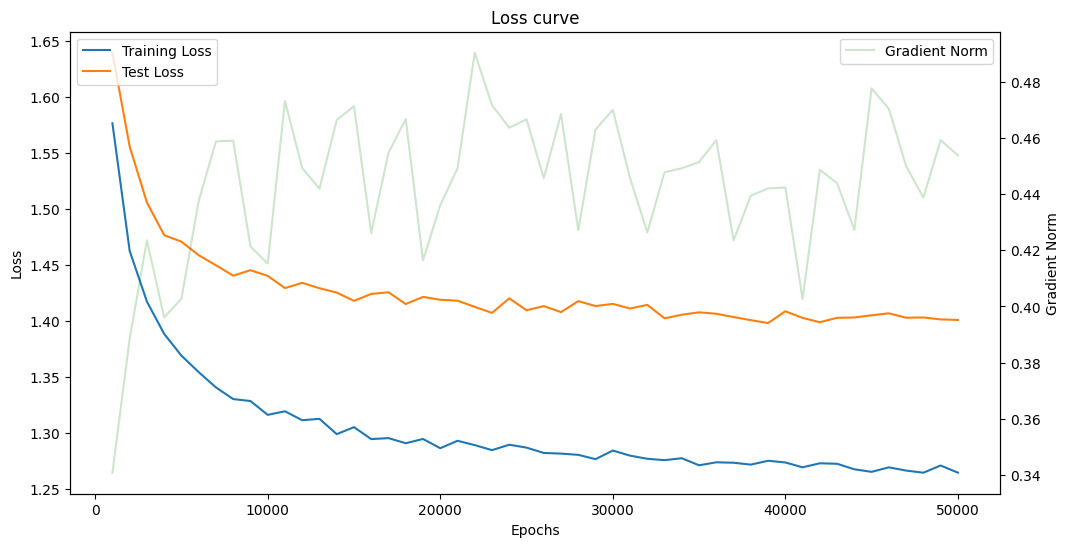

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot training and test loss on the left y-axis
ax1.plot(epoch_count, train_loss_values, label="Training Loss")
ax1.plot(epoch_count, test_loss_values, label="Test Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curve")

# Plot gradient norm on the right y-axis
ax2 = ax1.twinx()
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.2, label="Gradient Norm")
ax2.set_ylabel("Gradient Norm")

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [10]:
### Use model ###

@torch.inference_mode()
def evaluate(model, start='\n', length=500):
    hidden = model.init_hidden()
    prime_input = torch.tensor([char_to_num[c] for c in start])

    # Build up hidden state with input text
    for i in range(len(start) - 1):
        _, hidden = model(prime_input[i].unsqueeze(0).to(device), hidden)

    predicted = start

    # Generate new sequence based on hidden state
    input = prime_input[-1].unsqueeze(0)
    for _ in range(length):
        output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output, dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix
    
    return predicted


print(evaluate(model, 'In het begin ', 1000))

In het begin in de ark van de priesters. Laten Hij ook het dieren op de woorden van Juda siera, nam hen beschus uit Jerobeam kunnen waarin niets mij wijn;
U ben de HEERE.
30 Een dord van God.
2 Als Hij het jaarzes u geen ontrouw u zeven huiken;
zo voor altaar: Klereche zijn man? Dat Jakedeel moeten de in goedden en treve gerechtigheid doorschijnt en zijn weidegronden: en maakte hij zicht aan het hout nu verordening1 die mensen de woestijn Zijn zonen, en de 20
Daarom kunnen zij ons leggen zei tegen hem:
De bijbehorende voortruzpind. En Jonathan gingen zij uit van was, werd zeven,
de mij onder het begidde stuk in eeuwige heilige zan vertrouwt en hun dapperen, dat hij niet of weg nog zuchten in, die ik niet volkte echter aan de koning van Juda op een andere.
3 Voor Mij voor Grieft.
1: r 48:k brak als hart uw volk, wíj zelf toevoegen. Doe dag verloei. En *bekend redek, waaren.
15 Dan moon zag die mee door dit gelath, en welgegaan of dat u die toeviereen,
en betruid wordt, en ik er en zeide